In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as scp
import uproot
import matplotlib
from dash.testing.plugin import dashr
from docutils.languages.zh_cn import labels
from holoviews.plotting.bokeh.styles import font_size
from numba.core.target_extension import CPU
from rayoptics.parax.etendue import slp2na

font = {'weight' : 'bold',
        'size'   : 23}

matplotlib.rc('font', **font)

In [2]:
### Opticks Nexus Analysis

import h5py
isSafeFiles=True
SavePath="/home/argon/Projects/Ilker/CRAB_Diffusion/OpticksPaperImages"

In [3]:
def GetInfo(filePath):
    All={}
    subVal={}
    subsubVal={}
    f=h5py.File(filePath,"r")
    
    for folder in f:
        subVal={}
        for table in f[folder]:
            subsubVal={}
            for field in f[folder][table].dtype.fields.keys():
                subsubVal[field]=f[folder][table][field]
            subVal[table]=subsubVal
        All[folder]=subVal
    f.close()    
    return All

In [4]:
### Other Performance Results
Laptop_G4=GetInfo("/home/argon/Downloads/Performance/LaptopResults/runtime_G4_500.h5")["MC"]
Laptop_Opticks=GetInfo("/home/argon/Downloads/Performance/LaptopResults/runtime_Opticks_500.h5")["MC"]

ArgonTrx_G4=GetInfo("/home/argon/Downloads/Performance/Argon_Trx40/runtime_G4_500.h5")["MC"]
ArgonTrx_Opticks=GetInfo("/home/argon/Downloads/Performance/Argon_Trx40/runtime_Opticks.h5")["MC"]

I72700K_3060Ti=GetInfo("/home/argon/Downloads/Performance/3060TI/runtime_Opticks.h5")["MC"]
I72700K_=GetInfo("/home/argon/Downloads/Performance/3060TI/runtime_G4.h5")["MC"]

In [5]:

OpticksTimeRunPath="/home/argon/Downloads/Performance/CPB_rtx4090/runtime_Opticks.h5"
run1=GetInfo(OpticksTimeRunPath)["MC"]




In [6]:
G4TimeRunPath="/home/argon/Projects/Ilker/NewNexus/TimeRuns/G4/run1.h5"
run1G4=GetInfo(G4TimeRunPath)["MC"]


In [7]:
getWavelength=lambda E:1239.8/E # ev to nm 

### This is reading .txt files
def PerformanceInfo(Path):
    with open(Path,"r") as f:
        lines=f.readlines()
        
    Time=np.array([])
    Photons=np.array([])
    for line in lines:
    
        splited=line.split(",")
        if(splited[0]=="EventID"):
            continue
        Time=np.append(Time,float(splited[1].strip()))
        Photons=np.append(Photons,int(splited[2].strip()))
    return Time,Photons    

def EventSummary(key,Event,data,isPrint=True,boundaries=[30,33],det=[b'camWindow',b'PHOTOCATHODE' ]):
   
    if(Event==-1):
        EventLength=len(data["Timing"]["photons"])
        PMTHits_=np.array([])
        CameraHits_=np.array([])
        
        for evt in range(0,EventLength):
            EventHitMask=data[key]["event_id"]==evt
            #PhotonCountEventMask=data["Timing/event_id"]==evt
            #TotalPhoton=data["Timing/photons"][PhotonCountEventMask][0]
            #ExecutionTime=data["Timing/time"][PhotonCountEventMask][0]
            
            if(key=="Opticks_Hits"):
                tool="Opticks"
                CamHitMask=data[key]["boundary"][EventHitMask]==boundaries[0]
                PMTHitMask=data[key]["boundary"][EventHitMask]==boundaries[1]
             
            elif(key=="GEANT4_Optical_Hits"):
                tool="G4"
                CamHitMask=data[key]["name"][EventHitMask]==b'camWindow'
                PMTHitMask=data[key]["name"][EventHitMask]==b'PHOTOCATHODE'
            else:
                print(f"{key} is not valid!")
                break
                return -1
            
            CameraHits=len(data[key]["boundary"][EventHitMask][CamHitMask])
            PMTHits=len(data[key]["boundary"][EventHitMask][PMTHitMask])
            CameraHits=len(data[key]["name"][EventHitMask][CamHitMask])
            PMTHits=len(data[key]["name"][EventHitMask][PMTHitMask])  
            PMTHits_=np.append(PMTHits_,PMTHits)
            CameraHits_=np.append(CameraHits_,CameraHits)
        return PMTHits_,CameraHits_     
    
    else:
        EventHitMask=data[key]["event_id"]==Event
        PhotonCountEventMask=data["Timing"]["event_id"]==Event
        TotalPhoton=data["Timing"]["photons"][PhotonCountEventMask][0]
        ExecutionTime=data["Timing"]["time"][PhotonCountEventMask][0]
        wavelength=0
       
        if(key=="Opticks_Hits"):
            tool="Opticks"
            CamHitMask=data[key]["boundary"][EventHitMask]==boundaries[0]
            PMTHitMask=data[key]["boundary"][EventHitMask]==boundaries[1]
            
        elif(key=="GEANT4_Optical_Hits"):
            tool="G4"
            CamHitMask=data[key]["name"][EventHitMask]==det[0]
            PMTHitMask=data[key]["name"][EventHitMask]==det[1]   
        else:
            print("Key is not found !")
            
        PMTX=data[key]["x"][EventHitMask][PMTHitMask]
        PMTY=data[key]["y"][EventHitMask][PMTHitMask]
        PMTZ=data[key]["z"][EventHitMask][PMTHitMask]
        PMTT=data[key]["time"][EventHitMask][PMTHitMask]
        CamX=data[key]["x"][EventHitMask][CamHitMask]
        CamY=data[key]["y"][EventHitMask][CamHitMask]
        CamZ=data[key]["z"][EventHitMask][CamHitMask]
        CamT=data[key]["time"][EventHitMask][CamHitMask]
        CameraHits=len(data[key]["x"][EventHitMask][CamHitMask])
        PMTHits=len(data[key]["x"][EventHitMask][PMTHitMask])
        if ("wavelength" in data[key]):
            wavelength=data[key]["wavelength"][EventHitMask]

        
        if(isPrint):    
            print(f"------------------------ Event {Event} ({tool})------------------------")
            print(f"CameraHits  :  {CameraHits}       , PMTHits {PMTHits}")
            print(f"------------------------------------------------")
            print(f"TotalPhoton :  {TotalPhoton}   , Executation Time {ExecutionTime}")
        return np.array([TotalPhoton,ExecutionTime,PMTHits,CameraHits,wavelength],dtype=object),[PMTX,PMTY,PMTZ,PMTT],[CamX,CamY,CamZ,CamT]     

def GetDistributions(runs,key,bnd=[30,33]):
    Values={}
    Values["Photon"]=np.array([])
    Values["ExecutionTime"]=np.array([])
    Values["PMTHits"]=np.array([])
    Values["CameraHits"]=np.array([])

    for run in runs:
        ## Combine All the Photons and times
        Values["Photon"]=np.hstack((Values["Photon"],run['Timing/photons']))
        Values["ExecutionTime"]=np.hstack((Values["ExecutionTime"],run['Timing/time']))
        Results=EventSummary(key,-1,run,isPrint=True,boundaries=bnd)
        Values["PMTHits"]=np.hstack((Values["PMTHits"],Results[0]))
        Values["CameraHits"]=np.hstack((Values["CameraHits"],Results[1]))
        
    return Values    

In [8]:
print(f' Max Photon {np.max(np.sort(run1["Timing"]["photons"]/1e6))}  and Min Photon {np.min(np.sort(run1["Timing"]["photons"]/1e6))}')
print(f' Max Time {np.max(np.sort(run1["Timing"]["time"]))}  and Min Time {np.min(np.sort(run1["Timing"]["time"]))}')

print("-----------------------------------------")
print(f'(G4) Max Photon {np.max(np.sort(run1G4["Timing"]["photons"]/1e6))}  and Min Photon {np.min(np.sort(run1G4["Timing"]["photons"]/1e6))}')
print(f'(G4) Max Time {np.max(np.sort(run1G4["Timing"]["time"]))}  and Min Time {np.min(np.sort(run1G4["Timing"]["time"]))}')

 Max Photon 152.599876  and Min Photon 14.162887
 Max Time 2.23272054  and Min Time 0.210341181
-----------------------------------------
(G4) Max Photon 152.310827  and Min Photon 14.22512
(G4) Max Time 410.444352002  and Min Time 37.208084442


In [9]:
def applypolyfit(x,y,deg=1,cov=False):
    Slope=[]
    Intercept=[]
    Error=[]
    for p in range(0,len(x)):
        if(cov):
            s,e=np.polyfit(x[p],y[p],deg,cov=cov)
            Slope.append(s[0])
            Intercept.append(s[1])
            Error.append(e)
        else:
            s,i=np.polyfit(x[p],y[p],deg,cov=cov)
            Slope.append(s)
            Intercept.append(i)
    if (cov):        
        return Slope,Intercept,Error
    else:
        return Slope,Intercept
def getStandarError(covs):
    StandarError=[]
    Counter=0
    for cov in covs:
        StandarError.append(np.sqrt(np.diag(cov)))
    return StandarError    
def LinePLot(x,m,i):
    y=m*x+i
    return y
## sort the array and scale photons by million
def sortAndDataFrame(Time,Photon,name,type):
    sorted_indices=Time.argsort()
    Result={"Million Photons":Photon[sorted_indices]/1e6,"Computation Time(s)":Time[sorted_indices],"Device Name":name,"Type":type}
    Result['tmean']=np.mean(Result["Computation Time(s)"])
    Result['tstd']=np.std(Result["Computation Time(s)"])
    Result['tmedian']=np.median(Result["Computation Time(s)"])
    Result['tmax']=np.max(Result["Computation Time(s)"])
    Result['tmin']=np.min(Result["Computation Time(s)"])
    
    Result['pmean']=np.mean(Result["Million Photons"])
    Result['pstd']=np.std(Result["Million Photons"])
    Result['pmedian']=np.median(Result["Million Photons"])
    Result['pmax']=np.max(Result["Million Photons"])
    Result['pmin']=np.min(Result["Million Photons"])
    slope,intercept=np.polyfit(Result["Million Photons"],Result["Computation Time(s)"],1)
    Result["slope"]=slope
    Result["intercept"]=intercept
    return Result        


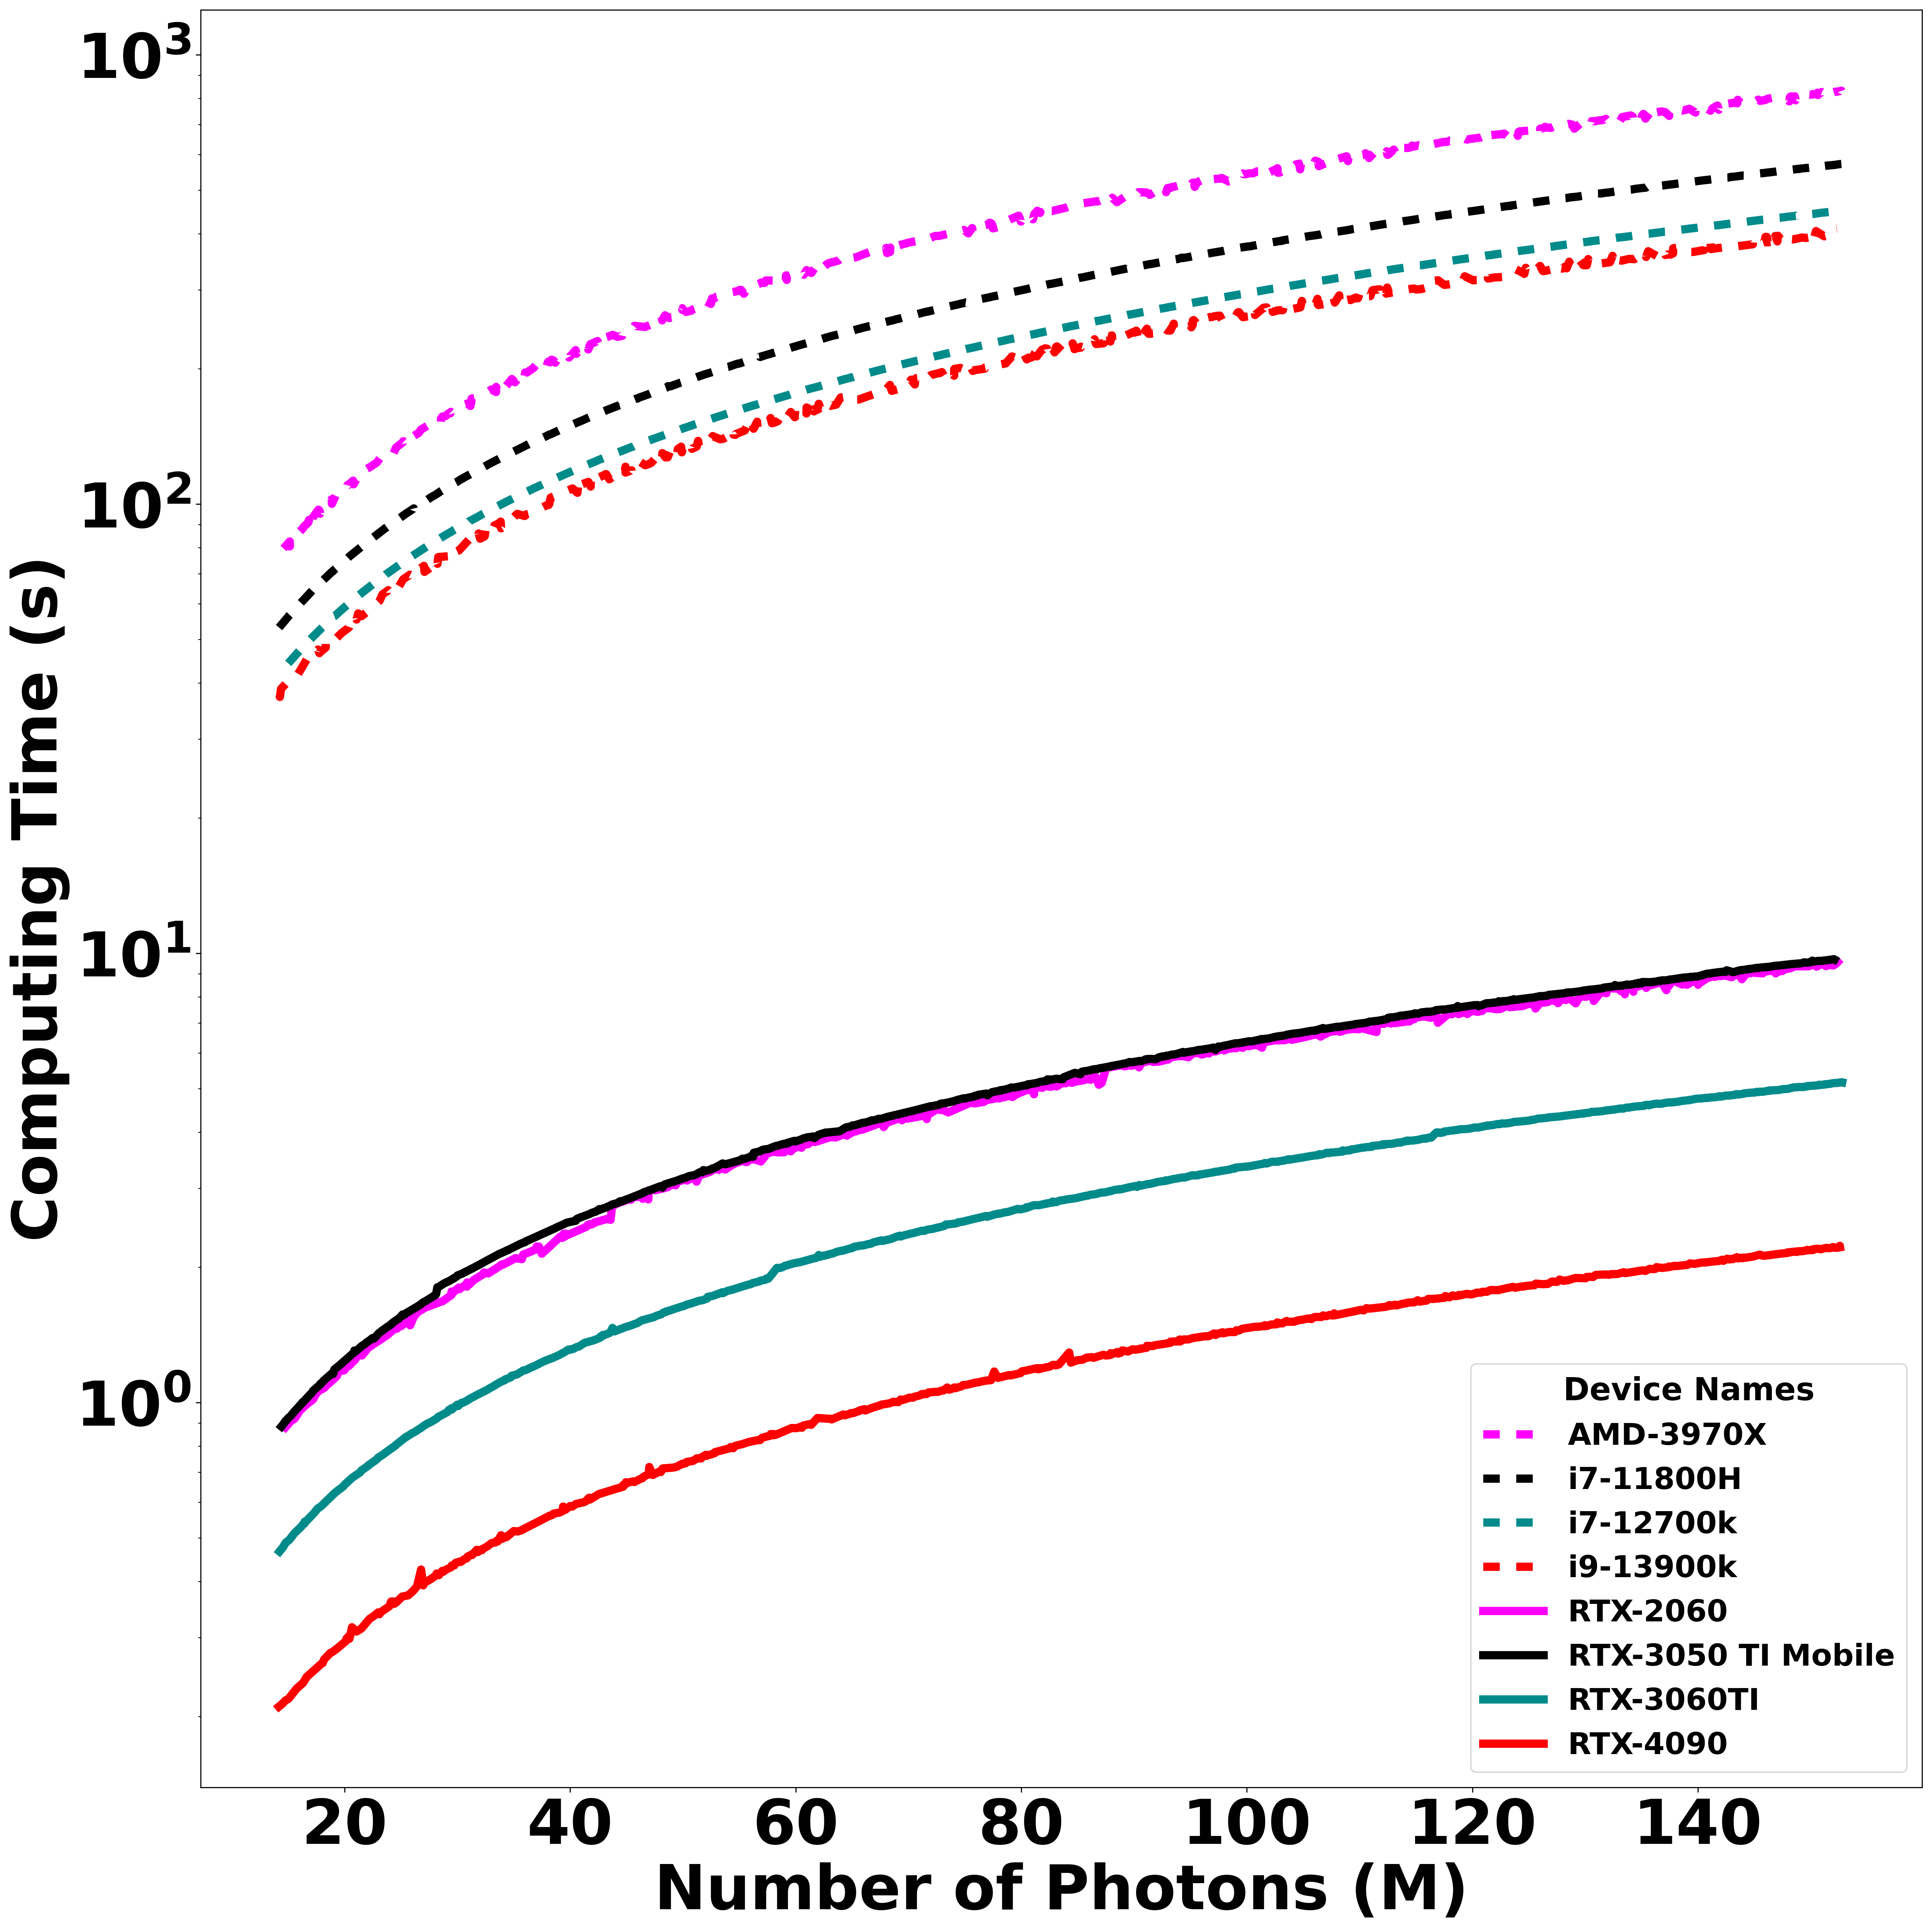

In [10]:
import seaborn as sns
## Lets Sort the arrays so that we dnt get weird behaviors
## CPUS 
isLegend=True
ArgonTrxSortedG4 = sortAndDataFrame(ArgonTrx_G4["Timing"]["time"],ArgonTrx_G4["Timing"]["photons"],'AMD-3970X','G4')
LaptopSorted_G4=sortAndDataFrame(Laptop_G4["Timing"]["time"],Laptop_G4["Timing"]["photons"],'i7-11800H','G4')
I72700KSorted_G4=sortAndDataFrame(I72700K_["Timing"]["time"],I72700K_["Timing"]["photons"],'i7-12700k','G4')
I913900_G4=sortAndDataFrame(run1G4["Timing"]["time"],run1G4["Timing"]["photons"],'i9-13900k','G4')
### GPU
ArgonTrxSortedOpticks = sortAndDataFrame(ArgonTrx_Opticks["Timing"]["time"],ArgonTrx_Opticks["Timing"]["photons"],'RTX-2060','Opticks')
LaptopSorted_Opticks=sortAndDataFrame(Laptop_Opticks["Timing"]["time"],Laptop_Opticks["Timing"]["photons"],'RTX-3050 TI Mobile','Opticks')
I72700KSorted_Opticks=sortAndDataFrame(I72700K_3060Ti["Timing"]["time"],I72700K_3060Ti["Timing"]["photons"],'RTX-3060TI','Opticks')
I913900Sorted_Opticks=sortAndDataFrame(run1["Timing"]["time"],run1["Timing"]["photons"],'RTX-4090','Opticks')
opacity=1                          
plt.figure(figsize=(20,20),dpi=300)
sns.lineplot(data=ArgonTrxSortedG4, x="Million Photons", y="Computation Time(s)",hue="Device Name",palette=['magenta'],linewidth=6,alpha=opacity,dashes=(2,2),legend=isLegend)
#sns.lineplot(x=ArgonTrxSortedG4["Million Photons"], y=LinePLot(ArgonTrxSortedG4["Million Photons"], ArgonTrxSortedG4["slope"], ArgonTrxSortedG4["intercept"]),color='green', linewidth=6, linestyle='dashed',alpha=0.4,)
sns.lineplot(data=LaptopSorted_G4, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["black"],linewidth=6,alpha=opacity,dashes=[(2, 2)],legend=isLegend)

#sns.lineplot(x=LaptopSorted_G4["Million Photons"], y=LinePLot(LaptopSorted_G4["Million Photons"], LaptopSorted_G4["slope"], LaptopSorted_G4["intercept"]),color='blue', linewidth=6, linestyle='dashed',alpha=0.4,)
sns.lineplot(data=I72700KSorted_G4, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["darkcyan"],linewidth=6,alpha=opacity,dashes=[(2, 2)],legend=isLegend)
#sns.lineplot(x=I72700KSorted_G4["Million Photons"], y=LinePLot(I72700KSorted_G4["Million Photons"], I72700KSorted_G4["slope"], I72700KSorted_G4["intercept"]),color='c', linewidth=6, linestyle='dashed',alpha=0.4,)
sns.lineplot(data=I913900_G4, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["red"],linewidth=6,alpha=opacity,dashes=[(2, 2)],legend=isLegend)

#sns.lineplot(x=I913900_G4["Million Photons"], y=LinePLot(I913900_G4["Million Photons"], I913900_G4["slope"], I913900_G4["intercept"]),color='red', linewidth=6, linestyle='dashed',alpha=0.4,)
sns.lineplot(data=ArgonTrxSortedOpticks, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["magenta"],linewidth=6,alpha=opacity,legend=isLegend)
#sns.lineplot(x=ArgonTrxSortedOpticks["Million Photons"], y=LinePLot(ArgonTrxSortedOpticks["Million Photons"], ArgonTrxSortedOpticks["slope"], ArgonTrxSortedOpticks["intercept"]),color='green', linewidth=6, linestyle='dashed',alpha=0.4)

sns.lineplot(data=LaptopSorted_Opticks, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["black"],linewidth=6,alpha=opacity,legend=isLegend)
#sns.lineplot(x=LaptopSorted_Opticks["Million Photons"], y=LinePLot(LaptopSorted_Opticks["Million Photons"], LaptopSorted_Opticks["slope"], LaptopSorted_Opticks["intercept"]),color='blue', linewidth=6, linestyle='dashed',alpha=0.4)
sns.lineplot(data=I72700KSorted_Opticks, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["darkcyan"],linewidth=6,alpha=opacity,legend=isLegend)
#sns.lineplot(x=I72700KSorted_Opticks["Million Photons"], y=LinePLot(I72700KSorted_Opticks["Million Photons"], I72700KSorted_Opticks["slope"], I72700KSorted_Opticks["intercept"]),color='c', linewidth=6, linestyle='dashed',alpha=0.4)
sns.lineplot(data=I913900Sorted_Opticks, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["red"],linewidth=6,alpha=opacity,legend=isLegend)
#sns.lineplot(x=I913900Sorted_Opticks["Million Photons"], y=LinePLot(I913900Sorted_Opticks["Million Photons"], I913900Sorted_Opticks["slope"], I913900Sorted_Opticks["intercept"]),color='red', linewidth=6, linestyle='dashed',alpha=0.4)

Labels=[ArgonTrxSortedG4["Device Name"]+"/"+ArgonTrxSortedOpticks["Device Name"],'_',   LaptopSorted_G4["Device Name"]+"/"+LaptopSorted_Opticks["Device Name"],'_',
I72700KSorted_G4["Device Name"]+"/"+I72700KSorted_Opticks["Device Name"],'_',
I913900_G4["Device Name"]+"/"+I913900Sorted_Opticks["Device Name"],'_']
#plt.suptitle("Performance Comparison",fontweight='bold',y=0.95,fontsize=40)
plt.xlabel("Number of Photons (M)",fontweight='bold',y=0.95,fontsize=45)
plt.ylabel("Computing Time (s)",fontweight='bold',fontsize=45)
#plt.legend(title="Device Names",loc="lower right",labels=Labels,fontsize=35)
plt.xticks(fontsize=45)
plt.yticks(fontsize=45)
plt.legend(title="Device Names", loc="lower right", frameon=True, fontsize=22)
plt.semilogy()
plt.tight_layout()
#plt.savefig(f"{SavePath}/Performance.png")
plt.show()


In [11]:
newdf=pd.DataFrame([ArgonTrxSortedG4, I72700KSorted_G4,LaptopSorted_G4,I913900_G4,ArgonTrxSortedOpticks,LaptopSorted_Opticks,I72700KSorted_Opticks,I913900Sorted_Opticks])

In [12]:
newdf['tmean']=newdf["Computation Time(s)"].apply(np.mean)
newdf['tstd']=newdf["Computation Time(s)"].apply(np.std)
newdf['tmedian']=newdf["Computation Time(s)"].apply(np.median)
newdf['tmax']=newdf["Computation Time(s)"].apply(np.max)
newdf['tmin']=newdf["Computation Time(s)"].apply(np.min)

newdf['pmean']=newdf["Million Photons"].apply(np.mean)
newdf['pstd']=newdf["Million Photons"].apply(np.std)
newdf['pmedian']=newdf["Million Photons"].apply(np.median)
newdf['pmax']=newdf["Million Photons"].apply(np.max)
newdf['pmin']=newdf["Million Photons"].apply(np.min)
slope,intercept,cov=applypolyfit(newdf["Million Photons"],newdf["Computation Time(s)"],deg=1,cov=True)
newdf["slope"]=slope
newdf["intercept"]=intercept
newdf["cov"]=cov
newdf["standarError"]=getStandarError(cov)

In [13]:
Stats=newdf.drop("Million Photons",axis=1)
Stats=Stats.drop("Computation Time(s)",axis=1)

SlopeData=pd.DataFrame({"Device Name":Stats["Device Name"],"Type":Stats["Type"],"Slope":Stats["slope"],"intercept":Stats["intercept"],"err":Stats["standarError"]})


In [14]:
RelativePercentDiff = lambda v1,v2:abs(v1-v2)/abs(np.mean([v1,v2]))*100
Absolute = lambda v1,v2:abs(v1-v2)
Ratio = lambda v1,v2:(v1/v2)
Rrnd = lambda v:round(v,3)
def GetPercents(Data,IndexC,IndexG):
    CPU=Data.iloc[IndexC[0]:IndexC[1]]
    GPU=Data.iloc[IndexG[0]:IndexG[1]]
    CSlope=CPU["Slope"][IndexC[0]]
    GSlope=GPU["Slope"][IndexG[0]]
    ErrCSlope=CPU["err"][IndexC[0]][0]
    ErrGSlope=GPU["err"][IndexG[0]][0]
   
    Error=np.sqrt((ErrCSlope/CSlope)**2+(ErrGSlope/GSlope)**2)
    
    RelativeDifference=RelativePercentDiff(CSlope,GSlope)
    AbsoluteDifference=Absolute(CSlope,GSlope)
    RatioDifference=Ratio(CSlope,GSlope)
    #pintercept=RelativePercentDiff(CPU["intercept"][IndexC[0]],GPU["intercept"][IndexG[0]])
    #ErrorOnIntercept=pintercept*np.sqrt((CPU["err"][IndexC[0]][1]/CPU["intercept"][IndexC[0]])**2+(GPU["err"][IndexG[0]][1]/GPU["intercept"][IndexG[0]])**2)
  
    dict=pd.DataFrame([{"D Name":f"{CPU['Device Name'][IndexC[0]]}/{GPU['Device Name'][IndexG[0]]}","Absolute Difference ":[Rrnd(AbsoluteDifference),Rrnd(AbsoluteDifference*Error)],"Ratio (%)":[Rrnd(RatioDifference),Rrnd(RatioDifference*Error)]}])
    print(dict)
    return dict
    

In [15]:
SlopeData.iloc[4:5]

,Device Name,Type,Slope,intercept,err
4,RTX-2060,Opticks,0.062664,-0.072483,"[7.486063961524462e-05, 0.006904388217028318]"


In [16]:
SlopeData

,Device Name,Type,Slope,intercept,err
0,AMD-3970X,G4,5.430801,-0.590158,"[0.005001009378260349, 0.46472352185966875]"
1,i7-12700k,G4,2.947012,0.008922,"[8.287503344826612e-05, 0.007502382801841402]"
2,i7-11800H,G4,3.741559,0.024837,"[0.00024708737147398146, 0.023112969567028154]"
3,i9-13900k,G4,2.639383,0.434629,"[0.0038602143317220095, 0.3501821119056411]"
4,RTX-2060,Opticks,0.062664,-0.072483,"[7.486063961524462e-05, 0.006904388217028318]"
5,RTX-3050 TI Mobile,Opticks,0.063987,-0.037711,"[2.0537652067349562e-05, 0.0019181779372293884]"
6,RTX-3060TI,Opticks,0.034061,-0.036331,"[2.315398437786604e-05, 0.0021945998832405148]"
7,RTX-4090,Opticks,0.014551,0.003818,"[6.3453132084585935e-06, 0.0005924063238698067]"


In [17]:

ArgonMachinePercent=GetPercents(SlopeData,IndexC=[0,1],IndexG=[4,5])
laptopPercent=GetPercents(SlopeData,IndexC=[2,3],IndexG=[5,6])
RTX4090Percent = GetPercents(SlopeData, IndexC=[3, 4], IndexG=[7, 8])
RTX3060TiPercent = GetPercents(SlopeData, IndexC=[1, 2], IndexG=[6, 7])
All=[ArgonMachinePercent,RTX4090Percent,RTX3060TiPercent,laptopPercent]

               D Name Absolute Difference         Ratio (%)
0  AMD-3970X/RTX-2060       [5.368, 0.008]  [86.666, 0.131]
                         D Name Absolute Difference         Ratio (%)
0  i7-11800H/RTX-3050 TI Mobile       [3.678, 0.001]  [58.474, 0.019]
               D Name Absolute Difference          Ratio (%)
0  i9-13900k/RTX-4090       [2.625, 0.004]  [181.385, 0.277]
                 D Name Absolute Difference         Ratio (%)
0  i7-12700k/RTX-3060TI       [2.913, 0.002]  [86.522, 0.059]


In [18]:
from tabulate import tabulate
table=tabulate(All,headers='keys')
print(table)

D Name                             Absolute Difference                        Ratio (%)
---------------------------------  -----------------------------------------  ------------------------------
0    AMD-3970X/RTX-2060            0    [5.368, 0.008]                        0    [86.666, 0.131]
Name: D Name, dtype: object        Name: Absolute Difference , dtype: object  Name: Ratio (%), dtype: object
0    i9-13900k/RTX-4090            0    [2.625, 0.004]                        0    [181.385, 0.277]
Name: D Name, dtype: object        Name: Absolute Difference , dtype: object  Name: Ratio (%), dtype: object
0    i7-12700k/RTX-3060TI          0    [2.913, 0.002]                        0    [86.522, 0.059]
Name: D Name, dtype: object        Name: Absolute Difference , dtype: object  Name: Ratio (%), dtype: object
0    i7-11800H/RTX-3050 TI Mobile  0    [3.678, 0.001]                        0    [58.474, 0.019]
Name: D Name, dtype: object        Name: Absolute Difference , dtype: object  N

In [19]:
Stats

,Device Name,Type,tmean,tstd,tmedian,tmax,tmin,pmean,pstd,pmedian,pmax,pmin,slope,intercept,cov,standarError
0,AMD-3970X,G4,450.348476,226.627545,459.016308,832.163743,79.664600,83.033546,41.721235,84.143171,152.725783,14.581022,5.430801,-0.590158,"[[2.5010094801447965e-05, -0.00207667686171222...","[0.005001009378260349, 0.46472352185966875]"
1,i7-12700k,G4,236.886235,122.727706,229.571663,450.806488,44.200322,80.378797,41.644779,77.907128,152.938359,14.996987,2.947012,0.008922,"[[6.868271169051228e-09, -5.520633736672343e-0...","[8.287503344826612e-05, 0.007502382801841402]"
2,i7-11800H,G4,314.420117,153.785069,305.685976,571.920661,53.110382,84.027893,41.101830,81.675033,152.827384,14.184689,3.741559,0.024837,"[[6.105216914192131e-08, -5.1300851344879036e-...","[0.00024708737147398146, 0.023112969567028154]"
3,i9-13900k,G4,217.122265,101.911407,218.915328,410.444352,37.208084,82.097835,38.591280,82.202986,152.310827,14.225120,2.639383,0.434629,"[[1.4901254686832002e-05, -0.00122336074675455...","[0.0038602143317220095, 0.3501821119056411]"
4,RTX-2060,Opticks,5.148613,2.479285,5.105873,9.562963,0.880433,83.319171,39.550822,83.556056,152.394165,14.750653,0.062664,-0.072483,"[[5.604115363603533e-09, -4.669302458691051e-0...","[7.486063961524462e-05, 0.006904388217028318]"
5,RTX-3050 TI Mobile,Opticks,5.328985,2.629592,5.473078,9.702795,0.884279,83.871560,41.094632,85.801732,152.107483,14.395989,0.063987,-0.037711,"[[4.217951524395077e-10, -3.537661759919582e-0...","[2.0537652067349562e-05, 0.0019181779372293884]"
6,RTX-3060TI,Opticks,2.885172,1.373904,2.916143,5.164451,0.465998,85.773466,40.332308,86.717040,152.793848,14.226379,0.034061,-0.036331,"[[5.361069925704647e-10, -4.5983755032559524e-...","[2.315398437786604e-05, 0.0021945998832405148]"
7,RTX-4090,Opticks,1.231235,0.582291,1.251525,2.232721,0.210341,84.351325,40.014691,85.180827,152.599876,14.162887,0.014551,0.003818,"[[4.026299971343909e-11, -3.3962373872678915e-...","[6.3453132084585935e-06, 0.0005924063238698067]"


In [20]:
Stats[Stats["Device Name"]==ArgonTrxSortedG4["Device Name"]][["slope","intercept"]]

,slope,intercept
0,5.430801,-0.590158
